# Fracture Modeling

Dhaval Kadia, Brandon Nelson

This notebook introduces synthetic fractures, specifically *linear fractures*, see the definitions and figure below from [Cleveland Clinic](https://my.clevelandclinic.org/health/diseases/skull-fracture) for more details.

- **Linear fracture**: This is the most common type of skull fracture. It usually happens in the bone toward the top of your head, above your ears.
- **Depressed fracture**: A break in your skull that pushes part of the bone closer to your brain. A depressed fracture can involve multiple cracks and fragments.
- **Basal (basilar) fracture**: A break of the bones at the base of your skull. This includes the bones behind your face and the bones that are internal in your brain that you can’t see.
- **Diastatic fracture**: A separation of the cranial sutures, or the bands of tissue that connect the bones in your skull together.
- **Combination or complex fractures**: Fractures that may involve several of the above types or multiple areas of fractured bone.

<img src="https://my.clevelandclinic.org/-/scassets/images/org/health/articles/skull-fracture" width="300">

This notebooks describes step 1 Synthetic Data Generation of the fracture modeling subproject:

<img src="attachment:47a48d66-ca8d-4530-970e-b8ef3ff1706d.png" width="600">

## Select a starting phantom

In [1]:
%pip install -q tomli-w pyvista pyransac3d

Note: you may need to restart the kernel to use updated packages.


In [2]:
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '10.5 yr NIHPD He

In [3]:
phantom = available_phantoms['6.5 yr NIHPD Head']()
# phantom.add_fracture=True
# phantom.resize(3*[240]) NOTE_K: keeping original size
# phantom.insert_lesion('EDH', mass_effect=True, seed=42, intensity=80, volume=5, edema=1)

pseudo-CT images not found; defaulting to otsu segmentation method


Check that fractures work for *UNC, NIHPD, and MIDA*

It looks like this `thresh` argument is important in setting the distance of the fracture to skull. Since this threshold is used in projecting the fracture to the skull surface we should find a better way of setting this value, we could also adjust it to determine the depth of the fracture. Currently thresh is in units of pixels (since its a threshold of the distance transform). We can look into ways to make this unitless, either a fraction the head size or something like that so that it will continue to work even if the base phantom is resized.

52.21495223820508 103.25419527151993
Starting random walk fracture generation with 200 iterations
Skull centroid at: [ 98 116 107]
Casting rays with random walk...
Random walk ray casting complete!


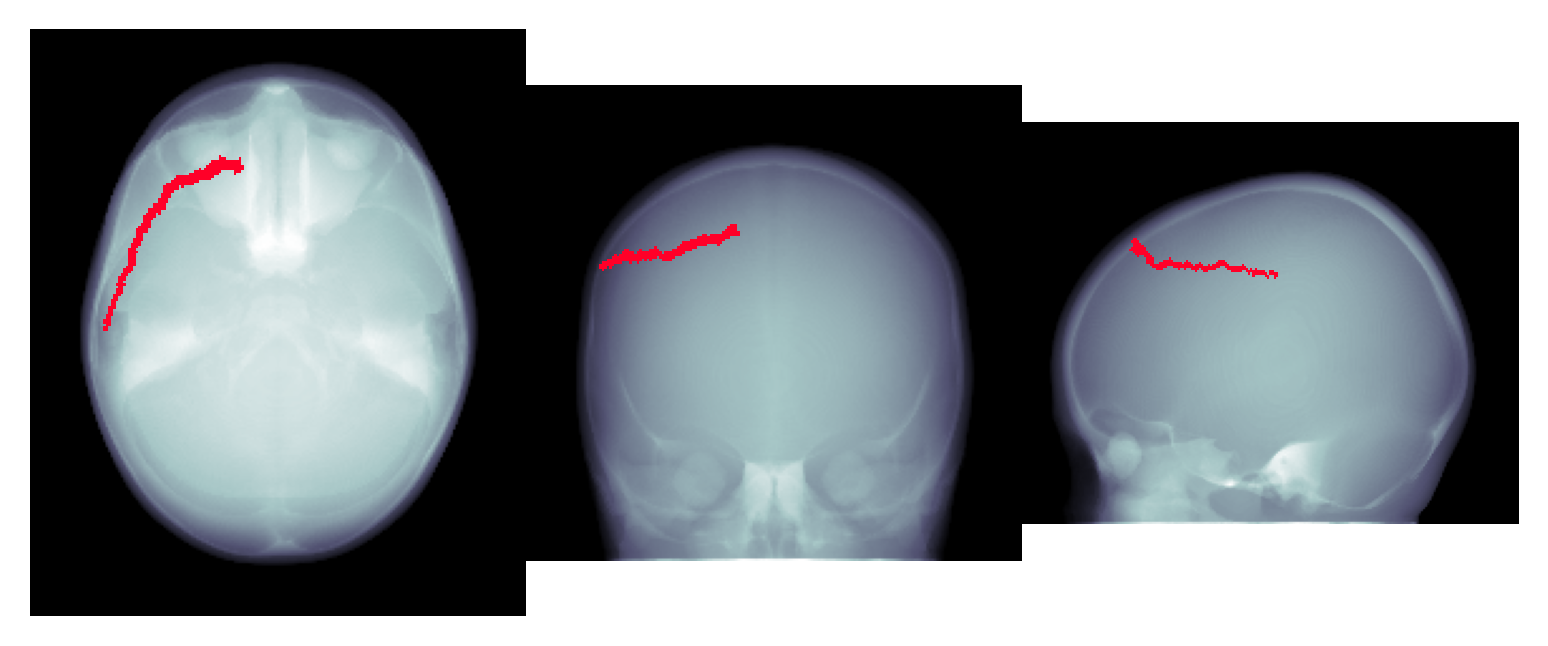

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random
from insilicoICH.lesion_definition import FractureLesion


fracture_lesion = FractureLesion('linear fracture', boundary=phantom.get_skull_map(), spacings=phantom.spacings, seed=9)
fracture_lesion.generate(fracture_length=200)

fractures = fracture_lesion.mask
fracture_mask = np.ma.masked_where(fractures == 0, fractures)
phantom.add_fractures = False
vol = phantom.get_CT_number_phantom()

f, axs = plt.subplots(1, 3, gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
for i, ax in enumerate(axs):
    ax.imshow(vol.mean(axis=i), cmap='bone')
    ax.imshow(fracture_mask.mean(axis=i), cmap='gist_rainbow', interpolation='none')
    ax.axis('off')

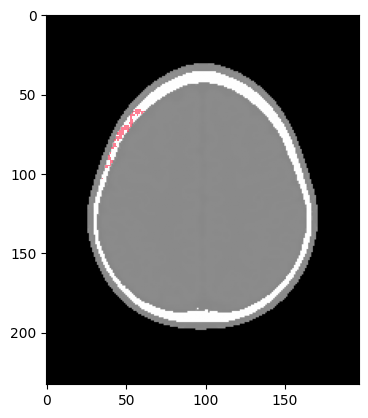

In [5]:
from skimage.measure import regionprops, label
from matplotlib import patches
c = 'g'

z_slice = fractures.mean(axis=(1,2)).argmax()
f, ax = plt.subplots()
ax.imshow(vol[z_slice], cmap='gray')
ax.imshow(fracture_mask[z_slice], cmap='gist_rainbow', interpolation='none', alpha=0.5)
# reg = regionprops(fractures.astype(np.uint8))[0]
# rect = patches.Rectangle((reg.bbox[1], reg.bbox[0]), reg.bbox[3] - reg.bbox[1],
#                           reg.bbox[2] - reg.bbox[0], linewidth=1, edgecolor=c, facecolor='none')
# ax.add_patch(rect)

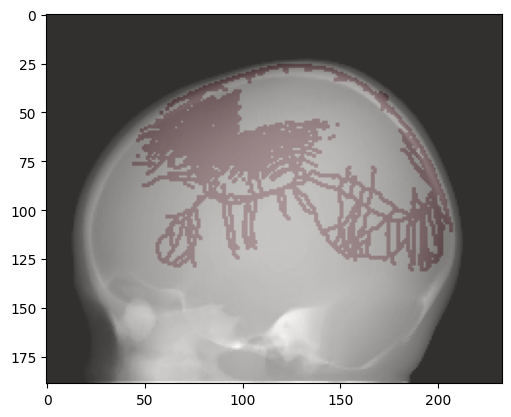

In [6]:
sutures = phantom.get_sutures()
plt.imshow(phantom.get_CT_number_phantom().mean(axis=2), cmap='gray')
plt.imshow(sutures.max(axis=2), cmap='Reds', alpha=0.2)

In [7]:
from VITools import Scanner

In [8]:
phantom.insert_lesion(fracture_lesion)


        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
Number of lesions: 1
  - Lesion 1: linear fracture, Volume: 0.32 mL, Center: (65, 73, 54)
Mass effect strength: 0.0

In [9]:
scanner = Scanner(phantom, 'Siemens_DefinitionFlash')

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.800000011920929-mm pixels (XY), 0.800000011920929-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing /tmp/

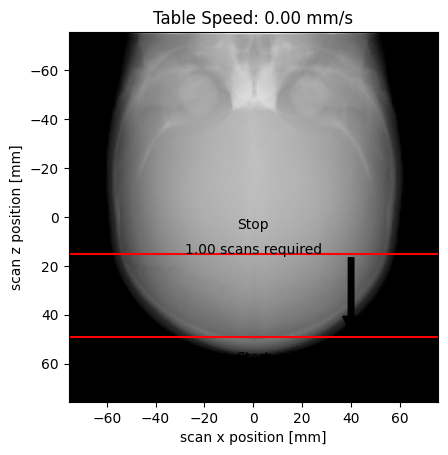

In [10]:
startZ, endZ = 15, 45
scanner.scout_view(startZ, endZ)

In [11]:
acquisition_technique = dict(
    mA=500,
    kVp=120,
    views=300,
    startZ=startZ,
    endZ=endZ,
    pitch=0
)
scanner.run_scan(**acquisition_technique)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/300 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 300/300 [06:14<00:00,  1.25s/it]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'VITools.scanner.Scanner'> default_series
        Scanner: Siemens_DefinitionFlash
        Simulation Platform: CATSIM
        

fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


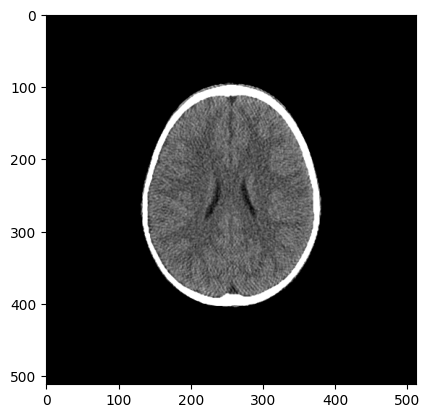

In [12]:
recon_technique = dict(
    kernel='soft',
    fov=250,
    slice_increment=1,
)
scanner.run_recon(**recon_technique)

import matplotlib.pyplot as plt
ww, wl = 80, 40
plt.imshow(scanner.recon[0], cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)

In [13]:
scanner.run_scan(kVp=120, mA=200, startZ=startZ, endZ=endZ, views=500)

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [10:14<00:00,  1.23s/it]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.



        <class 'VITools.scanner.Scanner'> default_series
        Scanner: Siemens_DefinitionFlash
        Simulation Platform: CATSIM
        
Recon: (27, 512, 512) 25.0 cm fov
Projections: (300, 64, 900)

In [14]:
kernels = ['bone', 'standard', 'soft']

recons = []
for kernel in kernels:
    scanner.run_recon(slice_thickness=1, kernel=kernel)
    recons.append(scanner.recon)

fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a n

In [15]:
from insilicoICH.study import MaskHandler

handler = MaskHandler(scanner)
handler.get_lesion_mask()

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.800000011920929-mm pixels (XY), 0.800000011920929-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'water']
* mu values (/cm): [0.05, 0.21]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.19]
* Thresholds (HU): [-1000.0, -100.0]
*********************************************
* Calculating volume fraction maps for 2 materials and 189 slices...
* Writing volume fraction files for 2 materials and 189 slices, plus the HU data...
* Writing /tmp/tmp2_gc8j5a/6.5 yr NIHPD Head/lesion_mask/lesion only/pha

  0%|          | 0/300 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated a total of     66 MB.


100%|██████████| 300/300 [02:15<00:00,  2.22it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


In [16]:
segmentations = handler.get_segmentation_mask()

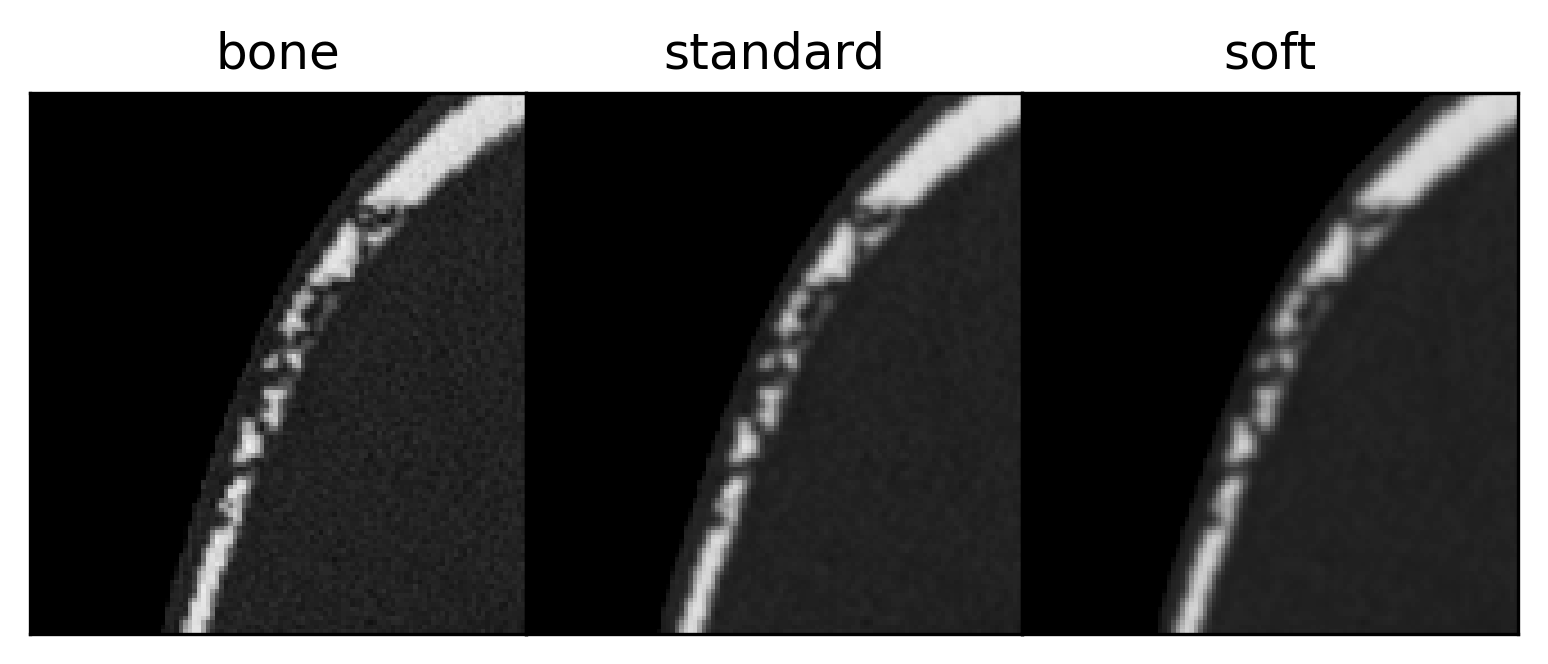

In [58]:
from utils import ctshow, center_crop
f, axs = plt.subplots(1, len(recons), gridspec_kw=dict(wspace=0, hspace=0), dpi=300)
z = segmentations.sum(axis=(1,2)).argmax()
for ax, recon, kernel in zip(axs.flatten(), recons, kernels):
    x1, x2 = (110, 220)
    y1, y2 = (140, 260)
    ctshow(recon[z][y1:y2, x1:x2], (1000, 400), fig=f, ax=ax)
    lesion_mask = handler.lesion_ids[0]['mask']
    lesion_roi = recon[lesion_mask]
    mean = lesion_roi.mean()
    std = lesion_roi.std()
    ax.set_title(f'{kernel}')
    # ax.set_title(f'{kernel}\nmean, std: {mean:2.1f}, {std:2.1f} HU', fontsize=6)